# Chapman ECG Classification with Optuna

Notebook này thực hiện:

1. Đọc dữ liệu Chapman từ file CSV.
2. Chia dữ liệu thành train, validation và test.
3. Huấn luyện mô hình `MultiScaleCNN`.
4. Tối ưu siêu tham số bằng Optuna.
5. Huấn luyện lại trên toàn bộ tập train.
6. Đánh giá Accuracy và Micro-F1 trên tập test.
7. Lưu siêu tham số tốt nhất vào `results_optuna.csv`.

> Đặt notebook sao cho đường dẫn `../data/chapman/csv/raw.csv` và các file `Chapman.py`, `MultiScaleCNN.py` có thể được import đúng.

## 1. Cài đặt thư viện

Bỏ dấu `#` nếu môi trường chưa cài các thư viện cần thiết.

In [1]:
# %pip install torch pandas numpy scikit-learn optuna

## 2. Import thư viện

In [2]:
import gc
import os
import random
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, random_split

from Chapman import ChapmanTestDataset, ChapmanTrainDataset
from Main import Main

## 3. Thiết lập seed và thiết bị

In [3]:
def set_seed(seed_value: int = 42) -> None:
    random.seed(seed_value)
    os.environ["PYTHONHASHSEED"] = str(seed_value)
    np.random.seed(seed_value)

    torch.manual_seed(seed_value)
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4090


## 4. Đọc và chia dữ liệu

In [4]:
DATA_PATH = Path("../data/chapman/csv/raw.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file dữ liệu: {DATA_PATH.resolve()}"
    )

data = pd.read_csv(DATA_PATH, header=None)

train_data_pd, test_data_pd = train_test_split(
    data,
    test_size=0.2,
    random_state=SEED,
)

data_train = ChapmanTrainDataset(train_data_pd)
data_test = ChapmanTestDataset(test_data_pd)

print("Total samples:", len(data))
print("Train + validation samples:", len(data_train))
print("Test samples:", len(data_test))

Total samples: 10646
Train + validation samples: 8516
Test samples: 2130


## 5. Chia tập train thành train và validation

In [5]:
VAL_RATIO = 0.2

n_total = len(data_train)
n_val = int(n_total * VAL_RATIO)
n_train = n_total - n_val

split_generator = torch.Generator().manual_seed(SEED)

train_set, val_set = random_split(
    data_train,
    [n_train, n_val],
    generator=split_generator,
)

print("Training samples:", len(train_set))
print("Validation samples:", len(val_set))

Training samples: 6813
Validation samples: 1703


## 6. Cấu hình huấn luyện

In [6]:
loss_fn = torch.nn.CrossEntropyLoss()

# Trên Windows/Jupyter, num_workers=0 thường ổn định hơn.
# Có thể tăng lên 2, 4 hoặc 8 nếu môi trường hỗ trợ.
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

## 7. Hàm tạo DataLoader

In [7]:
def create_loader(dataset, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

## 8. Hàm huấn luyện một epoch

In [8]:
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY).long()

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = running_loss / max(1, len(loader))
    accuracy = correct / max(1, total)

    return average_loss, accuracy

## 9. Hàm đánh giá

In [9]:
@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY).long()

        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_predictions.extend(predictions.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    average_loss = running_loss / max(1, len(loader))
    accuracy = correct / max(1, total)

    micro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="micro",
        zero_division=0,
    )

    return average_loss, accuracy, micro_f1

## 10. Hàm xây dựng mô hình

In [10]:
def build_model(params: dict) -> Main:
    kernel_sizes_arr = list(map(int, params["kernel_sizes"].split("_")))
    return Main(
        kernel_sizes=kernel_sizes_arr,
        upcoming_kernel_size=params["upcoming_kernel_size"],
        out_channels=params["out_channels"],
        num_se_res_blocks=params["num_se_res_blocks"],
        reduction=params["reduction"],
        n_heads=params["n_heads"],
        attention_num_layers=params["attention_num_layers"],
        dropout_rate=params["dropout_rate"],
    ).to(device)

## 11. Optuna objective

In [11]:
def objective(trial: optuna.Trial) -> float:
    model = None

    try:
        # Dùng cùng seed cho các trial để việc so sánh công bằng hơn.
        set_seed(SEED)

        params = {
            "lr": trial.suggest_float("lr", 1e-5, 1e-1, log=True),
            "batch_size": trial.suggest_categorical(
                "batch_size", [16, 32, 64]
            ),
            "weight_decay": trial.suggest_float(
                "weight_decay", 1e-6, 1e-3, log=True
            ),
            "dropout_rate": trial.suggest_float(
                "dropout_rate", 0.1, 0.5
            ),
            "kernel_sizes": trial.suggest_categorical(
                "kernel_sizes", [  
                    "3_5_7",
                    "3_5_9",
                    "5_7_9",
                    "5_7_11",
                    "5_9_11",
                    "7_9_11",
                    "7_9_13",
                    "7_11_13",
                    "9_11_13",
                    "9_11_15",
                    "9_13_15"
                ]
            ),
            "upcoming_kernel_size": trial.suggest_int(
                "upcoming_kernel_size", 2, 50
            ),
            "out_channels": trial.suggest_categorical(
                "out_channels", [32, 64, 128, 256, 512]
            ),
            "num_se_res_blocks": trial.suggest_int(
                "num_se_res_blocks", 1, 10
            ),
            "reduction": trial.suggest_categorical(
                "reduction", [4, 8, 16]
            ),
            "n_heads": trial.suggest_categorical(
                "n_heads", [4, 8, 16, 32]
            ),
            "attention_num_layers": trial.suggest_int(
                "attention_num_layers", 1,10
            ),
        }

        train_loader = create_loader(
            train_set,
            batch_size=params["batch_size"],
            shuffle=True,
        )

        val_loader = create_loader(
            val_set,
            batch_size=params["batch_size"],
            shuffle=False,
        )

        model = build_model(params)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=params["lr"],
            weight_decay=params["weight_decay"],
            betas=(0.9, 0.99),
        )

        max_epochs = 20
        best_val_micro_f1 = 0.0

        for epoch in range(max_epochs):
            train_loss, train_acc = train_one_epoch(
                model,
                train_loader,
                optimizer,
                loss_fn,
            )

            val_loss, val_acc, val_micro_f1 = evaluate(
                model,
                val_loader,
                loss_fn,
            )

            # Optuna tối ưu Micro-F1, đúng với nội dung in kết quả.
            trial.report(val_micro_f1, step=epoch)

            if trial.should_prune():
                raise optuna.TrialPruned()

            best_val_micro_f1 = max(
                best_val_micro_f1,
                val_micro_f1,
            )

            trial.set_user_attr(
                "last_epoch_metrics",
                {
                    "train_loss": float(train_loss),
                    "train_accuracy": float(train_acc),
                    "val_loss": float(val_loss),
                    "val_accuracy": float(val_acc),
                    "val_micro_f1": float(val_micro_f1),
                },
            )

        return best_val_micro_f1

    except torch.cuda.OutOfMemoryError:
        print(f"Trial {trial.number} bị CUDA Out Of Memory.")
        raise optuna.TrialPruned()

    finally:
        if model is not None:
            del model

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

## 12. Chạy Optuna study

In [12]:
def run_study(n_trials: int = 25) -> optuna.Study:
    sampler = optuna.samplers.TPESampler(seed=SEED)

    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=5,
    )

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=pruner,
        study_name="chapman_multiscale_cnn",
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=1,
        gc_after_trial=True,
    )

    print("Best validation Micro-F1:", study.best_value)
    print("Best parameters:")
    print(study.best_params)

    return study

Chạy cell dưới đây để bắt đầu tìm kiếm siêu tham số. Có thể giảm `N_TRIALS` khi muốn kiểm tra nhanh.

In [13]:
N_TRIALS = 200

study = run_study(n_trials=N_TRIALS)
best_params = study.best_params

[I 2026-07-15 07:29:23,208] A new study created in memory with name: chapman_multiscale_cnn
[I 2026-07-15 07:34:39,775] Trial 0 finished with value: 0.9448032883147387 and parameters: {'lr': 0.00031489116479568613, 'batch_size': 16, 'weight_decay': 2.9380279387035354e-06, 'dropout_rate': 0.16239780813448107, 'kernel_sizes': '7_9_11', 'upcoming_kernel_size': 27, 'out_channels': 128, 'num_se_res_blocks': 4, 'reduction': 8, 'n_heads': 32, 'attention_num_layers': 2}. Best is trial 0 with value: 0.9448032883147387.
[I 2026-07-15 07:34:40,459] Trial 1 pruned. 


Trial 1 bị CUDA Out Of Memory.


[I 2026-07-15 07:38:26,954] Trial 2 finished with value: 0.9677040516735174 and parameters: {'lr': 0.000132965214572995, 'batch_size': 64, 'weight_decay': 1.6736010167825795e-06, 'dropout_rate': 0.4947547746402069, 'kernel_sizes': '9_13_15', 'upcoming_kernel_size': 32, 'out_channels': 512, 'num_se_res_blocks': 7, 'reduction': 4, 'n_heads': 32, 'attention_num_layers': 5}. Best is trial 2 with value: 0.9677040516735174.
[I 2026-07-15 07:46:08,084] Trial 3 finished with value: 0.35466823253082796 and parameters: {'lr': 0.0012329098365270509, 'batch_size': 16, 'weight_decay': 1.2424747083660194e-06, 'dropout_rate': 0.3545641645055122, 'kernel_sizes': '9_13_15', 'upcoming_kernel_size': 41, 'out_channels': 512, 'num_se_res_blocks': 6, 'reduction': 8, 'n_heads': 32, 'attention_num_layers': 9}. Best is trial 2 with value: 0.9677040516735174.
[I 2026-07-15 07:52:03,269] Trial 4 finished with value: 0.9459776864357017 and parameters: {'lr': 1.0661259689433896e-05, 'batch_size': 16, 'weight_decay

Trial 19 bị CUDA Out Of Memory.


[I 2026-07-15 09:06:10,157] Trial 20 pruned. 
[I 2026-07-15 09:12:48,147] Trial 21 finished with value: 0.9647680563711099 and parameters: {'lr': 4.5429167407453136e-05, 'batch_size': 32, 'weight_decay': 1.7529731728332255e-05, 'dropout_rate': 0.4829351685666884, 'kernel_sizes': '3_5_7', 'upcoming_kernel_size': 33, 'out_channels': 512, 'num_se_res_blocks': 9, 'reduction': 4, 'n_heads': 32, 'attention_num_layers': 10}. Best is trial 7 with value: 0.9694656488549618.
[I 2026-07-15 09:19:22,285] Trial 22 finished with value: 0.9630064591896653 and parameters: {'lr': 9.649402720108591e-05, 'batch_size': 32, 'weight_decay': 1.3343451273346183e-05, 'dropout_rate': 0.45845145600126985, 'kernel_sizes': '3_5_7', 'upcoming_kernel_size': 37, 'out_channels': 512, 'num_se_res_blocks': 8, 'reduction': 4, 'n_heads': 32, 'attention_num_layers': 10}. Best is trial 7 with value: 0.9694656488549618.
[I 2026-07-15 09:21:13,587] Trial 23 pruned. 
[I 2026-07-15 09:23:14,513] Trial 24 pruned. 
[I 2026-07-15 

...

Trial 138 bị CUDA Out Of Memory.


[I 2026-07-15 14:22:43,553] Trial 139 finished with value: 0.9682912507339988 and parameters: {'lr': 0.00011606610298868146, 'batch_size': 32, 'weight_decay': 0.00017507751726854556, 'dropout_rate': 0.32822273982376293, 'kernel_sizes': '9_11_15', 'upcoming_kernel_size': 26, 'out_channels': 512, 'num_se_res_blocks': 7, 'reduction': 8, 'n_heads': 32, 'attention_num_layers': 4}. Best is trial 124 with value: 0.9729888432178508.
[I 2026-07-15 14:28:44,365] Trial 140 finished with value: 0.9706400469759249 and parameters: {'lr': 7.069904840234877e-05, 'batch_size': 16, 'weight_decay': 0.00021496807699883434, 'dropout_rate': 0.26193113025348835, 'kernel_sizes': '9_11_15', 'upcoming_kernel_size': 30, 'out_channels': 512, 'num_se_res_blocks': 7, 'reduction': 8, 'n_heads': 32, 'attention_num_layers': 3}. Best is trial 124 with value: 0.9729888432178508.
[I 2026-07-15 14:30:58,886] Trial 141 pruned. 
[I 2026-07-15 14:37:01,729] Trial 142 finished with value: 0.9665296535525543 and parameters: {'

Trial 169 bị CUDA Out Of Memory.


[I 2026-07-15 16:10:58,275] Trial 170 pruned. 
[I 2026-07-15 16:12:27,987] Trial 171 pruned. 
[I 2026-07-15 16:13:56,842] Trial 172 pruned. 
[I 2026-07-15 16:18:10,482] Trial 173 finished with value: 0.9694656488549618 and parameters: {'lr': 0.00011677277649697363, 'batch_size': 32, 'weight_decay': 2.3351926751009544e-06, 'dropout_rate': 0.47224171373045964, 'kernel_sizes': '9_11_15', 'upcoming_kernel_size': 23, 'out_channels': 512, 'num_se_res_blocks': 8, 'reduction': 8, 'n_heads': 32, 'attention_num_layers': 5}. Best is trial 124 with value: 0.9729888432178508.
[I 2026-07-15 16:19:37,664] Trial 174 pruned. 
[I 2026-07-15 16:21:07,544] Trial 175 pruned. 
[I 2026-07-15 16:25:46,937] Trial 176 finished with value: 0.9641808573106283 and parameters: {'lr': 9.59381713882495e-05, 'batch_size': 32, 'weight_decay': 2.146828679812239e-06, 'dropout_rate': 0.4817643313632779, 'kernel_sizes': '9_11_15', 'upcoming_kernel_size': 26, 'out_channels': 512, 'num_se_res_blocks': 7, 'reduction': 4, 'n_h

Best validation Micro-F1: 0.9735760422783324
Best parameters:
{'lr': 0.00014401199502005196, 'batch_size': 32, 'weight_decay': 1.7200095601516344e-06, 'dropout_rate': 0.23290794820163344, 'kernel_sizes': '9_11_15', 'upcoming_kernel_size': 23, 'out_channels': 512, 'num_se_res_blocks': 6, 'reduction': 8, 'n_heads': 32, 'attention_num_layers': 3}


## 13. Xem kết quả các trial

In [14]:
trials_df = study.trials_dataframe()
trials_df.head()

,number,value,datetime_start,datetime_complete,duration,params_attention_num_layers,params_batch_size,params_dropout_rate,params_kernel_sizes,params_lr,params_n_heads,params_num_se_res_blocks,params_out_channels,params_reduction,params_upcoming_kernel_size,params_weight_decay,user_attrs_last_epoch_metrics,state
0,0,0.944803,2026-07-15 07:29:23.209566,2026-07-15 07:34:39.775258,0 days 00:05:16.565692,2,16,0.162398,7_9_11,0.000315,32,4,128,8,27,0.000003,"{'train_loss': 0.12278993035220659, 'train_acc...",COMPLETE
1,1,NaN,2026-07-15 07:34:40.125952,2026-07-15 07:34:40.459300,0 days 00:00:00.333348,4,32,0.139069,7_9_11,0.000018,32,10,32,8,11,0.000008,NaN,PRUNED
2,2,0.967704,2026-07-15 07:34:40.676099,2026-07-15 07:38:26.954753,0 days 00:03:46.278654,5,64,0.494755,9_13_15,0.000133,32,7,512,4,32,0.000002,"{'train_loss': 0.06390039953098536, 'train_acc...",COMPLETE
3,3,0.354668,2026-07-15 07:38:27.202362,2026-07-15 07:46:08.084168,0 days 00:07:40.881806,9,16,0.354564,9_13_15,0.001233,32,6,512,8,41,0.000001,"{'train_loss': 1.354501659321673, 'train_accur...",COMPLETE
4,4,0.945978,2026-07-15 07:46:08.305421,2026-07-15 07:52:03.269646,0 days 00:05:54.964225,8,16,0.235046,7_9_11,0.000011,16,3,512,16,3,0.000002,"{'train_loss': 0.07324799890695534, 'train_acc...",COMPLETE


## 14. Huấn luyện mô hình cuối cùng và đánh giá test

In [15]:
from sklearn.metrics import confusion_matrix

def safe_divide(a, b):
    return np.divide(
        a,
        b,
        out=np.zeros_like(a, dtype=float),
        where=b != 0
    )

def compute_metrics(all_labels, all_preds, class_names):
    num_classes = len(class_names)
    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))
    total_support = cm.sum()
    support = cm.sum(axis=1)

    TP = np.diag(cm)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = cm.sum() - (TP + FP + FN)

    precision = safe_divide(TP, TP + FP)
    recall = safe_divide(TP, TP + FN)
    specificity = safe_divide(TN, TN + FP)
    f1 = safe_divide(2 * precision * recall, precision + recall)
    acc_per_class = safe_divide(TP + TN, TP + TN + FP + FN)

    weights = safe_divide(support, total_support)
    macro_precision = precision.mean()
    macro_recall = recall.mean()
    macro_specificity = specificity.mean()
    macro_f1 = f1.mean()

    weighted_precision = (precision * weights).sum()
    weighted_recall = (recall * weights).sum()
    weighted_specificity = (specificity * weights).sum()
    weighted_f1 = (f1 * weights).sum()
    
    overall_acc = TP.sum() / max(1, total_support)
    micro_precision = overall_acc
    micro_recall = overall_acc
    micro_f1 = overall_acc
    
    FP_s = FP.sum()
    TN_s = TN.sum()
    micro_specificity = TN_s / (TN_s + FP_s) if (TN_s + FP_s) > 0 else 0.0

    rows = []
    for i, name in enumerate(class_names):
        rows.append({
            "Class": name,
            "Accuracy": f"{acc_per_class[i] * 100:.2f}%",
            "Precision": f"{precision[i]:.4f}",
            "Recall": f"{recall[i]:.4f}",
            "Specificity": f"{specificity[i]:.4f}",
            "F1 Score": f"{f1[i]:.4f}",
            "Support": int(support[i])
        })
    
    for avg_name, p, r, s, f in [
        ("Macro avg", macro_precision, macro_recall, macro_specificity, macro_f1),
        ("Micro avg", micro_precision, micro_recall, micro_specificity, micro_f1),
        ("Weighted avg", weighted_precision, weighted_recall, weighted_specificity, weighted_f1)
    ]:
        rows.append({
            "Class": avg_name, "Accuracy": "", "Precision": f"{p:.4f}",
            "Recall": f"{r:.4f}", "Specificity": f"{s:.4f}", "F1 Score": f"{f:.4f}", "Support": int(total_support)
        })

    rows.append({
        "Class": "Overall", "Accuracy": f"{overall_acc * 100:.2f}%", "Precision": "",
        "Recall": "", "Specificity": "", "F1 Score": "", "Support": int(total_support)
    })

    return {
        "confusion_matrix": cm, "df_metrics": pd.DataFrame(rows), "overall_acc": overall_acc,
        "macro_precision": macro_precision, "macro_recall": macro_recall, "macro_specificity": macro_specificity, "macro_f1": macro_f1,
        "weighted_precision": weighted_precision, "weighted_recall": weighted_recall, "weighted_specificity": weighted_specificity, "weighted_f1": weighted_f1,
        "micro_precision": micro_precision, "micro_recall": micro_recall, "micro_specificity": micro_specificity, "micro_f1": micro_f1
    }

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
def plot_confusion_matrix(cm, class_names, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[0], linewidths=0.5)
    axes[0].set_title("Confusion Matrix - Counts")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sum, out=np.zeros_like(cm, dtype=float), where=row_sum != 0)

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
    axes[1].set_title("Confusion Matrix - Normalized")
    axes[1].set_xlabel("Predicted Label")
    axes[1].set_ylabel("True Label")
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# Metrics table
def plot_metrics_table(df_metrics, save_path):
    df_plot = df_metrics.copy()
    col_labels = list(df_plot.columns)
    cell_text = df_plot.values.tolist()
    n_rows = len(cell_text)

    fig, ax = plt.subplots(figsize=(14, 0.6 * n_rows + 1.8))
    ax.axis("off")
    table = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.15, 1.6)
    
    ax.set_title("Metrics Summary Table", fontsize=14, fontweight="bold", pad=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

In [17]:
def train_final_and_test(
    best_params: dict,
    num_epochs: int,
):
    print("Best parameters:")
    print(best_params)

    set_seed(SEED)

    batch_size = best_params["batch_size"]

    full_train_loader = create_loader(
        data_train,
        batch_size=batch_size,
        shuffle=True,
    )

    test_loader = create_loader(
        data_test,
        batch_size=batch_size,
        shuffle=False,
    )

    model = build_model(best_params)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"],
        betas=(0.9, 0.99),
    )

    training_history = []

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            full_train_loader,
            optimizer,
            loss_fn,
        )

        training_history.append(
            {
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_accuracy": train_acc,
            }
        )

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc * 100:.2f}%"
        )

    test_loss, test_acc, test_micro_f1 = evaluate(
        model,
        test_loader,
        loss_fn,
    )

    
    CLASS_NAMES  = ["AFIB", "GSVT", "SB", "SR"]   # adjust if needed

    # Confusion matrix
    plot_confusion_matrix(
        compute_metrics(
            [label for _, label in data_test],
            [model(x.unsqueeze(0).to(device)).argmax(dim=1).item() for x, _ in data_test],
            class_names=CLASS_NAMES,
        )["confusion_matrix"],
        class_names=CLASS_NAMES,
        save_path="confusion_matrix.png",
    )
    
    plot_metrics_table(
        compute_metrics(
            [label for _, label in data_test],
            [model(x.unsqueeze(0).to(device)).argmax(dim=1).item() for x, _ in data_test],
            class_names=CLASS_NAMES,
        )["df_metrics"],
        save_path="metrics_summary_table.png",
    )
    
    cm_path = os.path.join("confusion_matrix.png")
    table_path = os.path.join("metrics_table.png")

    print(f"Confusion matrix: {cm_path}")
    print(f"Metrics summary table: {table_path}")

    result_row = {
        **best_params,
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "test_micro_f1": test_micro_f1,
        "num_epochs": num_epochs,
    }

    pd.DataFrame([result_row]).to_csv(
        "results_optuna.csv",
        index=False,
    )

    pd.DataFrame(training_history).to_csv(
        "training_history.csv",
        index=False,
    )

    return model, pd.DataFrame(training_history), result_row

Best parameters:
{'lr': 0.00014401199502005196, 'batch_size': 32, 'weight_decay': 1.7200095601516344e-06, 'dropout_rate': 0.23290794820163344, 'kernel_sizes': '9_11_15', 'upcoming_kernel_size': 23, 'out_channels': 512, 'num_se_res_blocks': 6, 'reduction': 8, 'n_heads': 32, 'attention_num_layers': 3}
Epoch 01/80 | train_loss=0.3640 | train_acc=86.48%
Epoch 02/80 | train_loss=0.2003 | train_acc=93.15%
Epoch 03/80 | train_loss=0.1832 | train_acc=94.05%
Epoch 04/80 | train_loss=0.1646 | train_acc=94.40%
Epoch 05/80 | train_loss=0.1381 | train_acc=95.27%
Epoch 06/80 | train_loss=0.1283 | train_acc=95.61%
Epoch 07/80 | train_loss=0.1211 | train_acc=95.84%
Epoch 08/80 | train_loss=0.1112 | train_acc=96.40%
Epoch 09/80 | train_loss=0.1049 | train_acc=96.51%
Epoch 10/80 | train_loss=0.0932 | train_acc=96.82%
Epoch 11/80 | train_loss=0.0863 | train_acc=97.15%
Epoch 12/80 | train_loss=0.0770 | train_acc=97.45%
Epoch 13/80 | train_loss=0.0742 | train_acc=97.67%
Epoch 14/80 | train_loss=0.0694 | tr

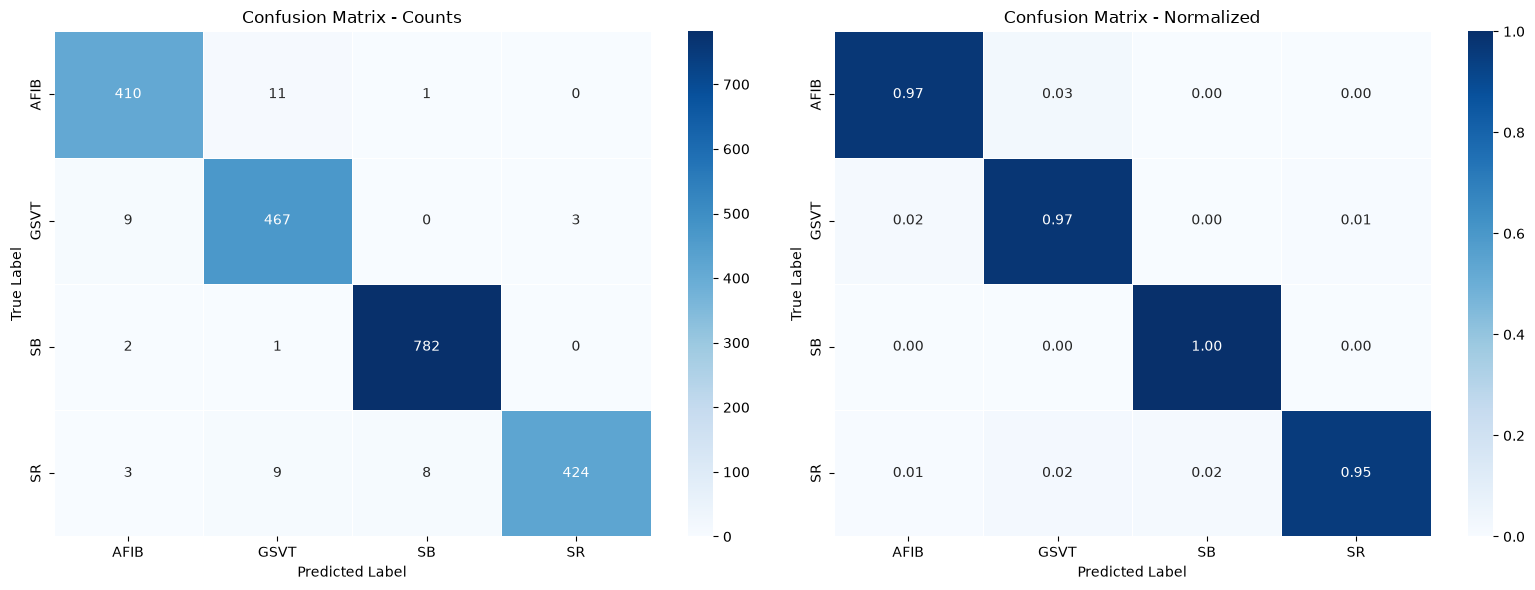

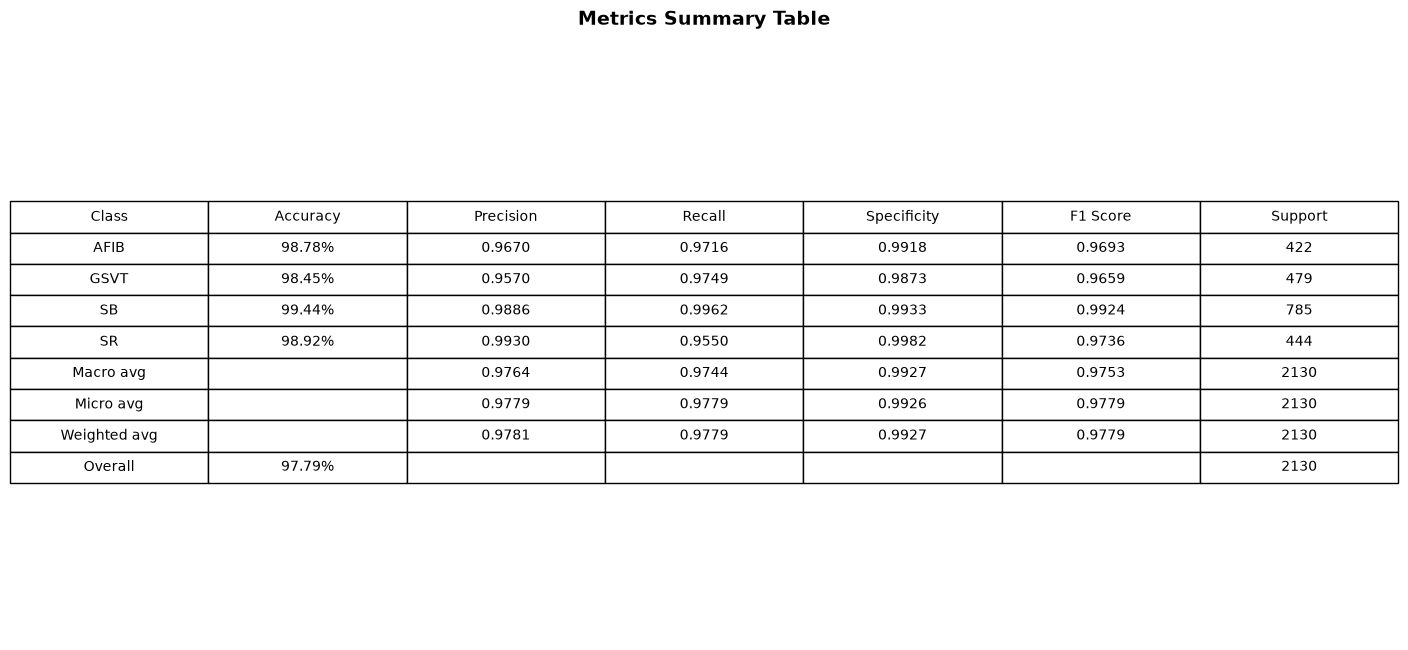

Confusion matrix: confusion_matrix.png
Metrics summary table: metrics_table.png


In [18]:
final_model, history_df, final_result = train_final_and_test(
    best_params,
    num_epochs=80,
)

## 15. Xem kết quả cuối cùng

In [19]:
pd.DataFrame([final_result])

,lr,batch_size,weight_decay,dropout_rate,kernel_sizes,upcoming_kernel_size,out_channels,num_se_res_blocks,reduction,n_heads,attention_num_layers,test_loss,test_accuracy,test_micro_f1,num_epochs
0,0.000144,32,0.000002,0.232908,9_11_15,23,512,6,8,32,3,0.106236,0.977934,0.977934,80


## 16. Vẽ lịch sử huấn luyện

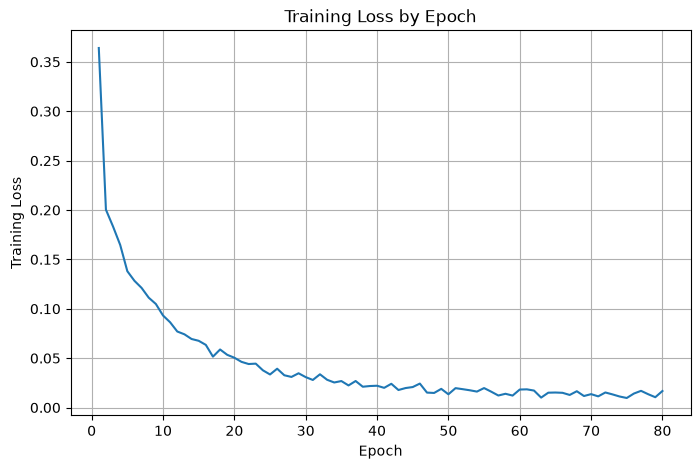

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss by Epoch")
plt.grid(True)
plt.show()

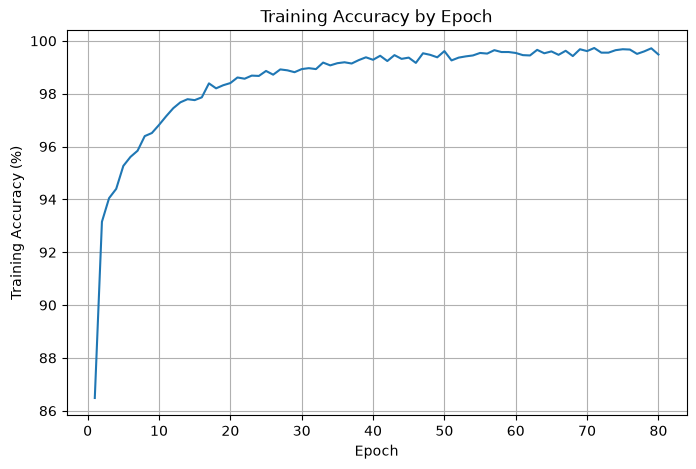

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"] * 100,
)
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy by Epoch")
plt.grid(True)
plt.show()